# Purpose

This script is used to apply the 4 timseries cross-validation models to the the test data (2015/2022). This instances uses the operational model that has 27 features and is currently (May 2025) deployed in the app

In [41]:
#high level modules
import os
import importlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
# custom modules
fun_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/functions/"

def import_from_path(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

import_from_path("universals", os.path.join(fun_dir, "universal_functions.py"))
from universals import load_pickle_file, twotemp_labels_features_test, predict_2_values_test, return_test_error_metrics

import_from_path("vis", os.path.join(fun_dir, "vis_functions.py"))
from vis import ts_plot, create_scatter_plot_test

We need to read in the transformed test data, apply the models, and save the resictions.

In [43]:
# import test data
file_path = os.path.expanduser("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/")

test_fn = os.path.join(file_path, "test.csv")
with open(test_fn) as f:
    test = pd.read_csv(f, sep=',')

And read in the z score mean/sd values.

In [44]:
transform = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/data/mu_sigma.csv", index_col=0)

t_mean_1m = transform['mean'].get('mean_1m_temp_degC')
t_std_1m = transform['sd'].get('mean_1m_temp_degC')

t_mean_05m = transform['mean'].get('mean_0_5m_temp_degC')
t_std_05m = transform['sd'].get('mean_0_5m_temp_degC')

And we'll mimic zero and full pump values to see if the network is sensitive

In [45]:
t_pump_mean = transform["mean"].get("pump_cfs")
t_pump_sd = transform["sd"].get("pump_cfs")
zero_pump = (0 - t_pump_mean) / t_pump_sd
full_pump = (550 - t_pump_mean) / t_pump_sd

Now we need to apply the models to the test data, but first we need to format the data for the models

In [46]:
# arrange the data by date
test['date'] = pd.to_datetime(test['date'])
test = test.sort_values(by='date')
#test = test.loc[test['date'].between('2022-07-01', '2022-09-11')]

In [47]:
test.columns

Index(['date', 'mean_1m_temp_degC', 'mean_0_5m_temp_degC',
       'mean_1m_temp_degC_m1', 'mean_0_5m_temp_degC_m1',
       'total_solar_radiation', 'total_solar_radiation_m1',
       'total_solar_radiation_m2', 'mean_air_temp', 'min_air_temp',
       'max_air_temp', 'mean_air_temp_m1', 'min_air_temp_m1',
       'max_air_temp_m1', 'mean_rel_hum_m1', 'mean_rel_hum_m2', 'pump_cfs_m1',
       'pump_cfs_m2', 'pump_cfs_m3', 'mean_wind', 'max_wind', 'mean_wind_m1',
       'max_wind_m1', 'nf_cfs_m1', 'nf_cfs_m2', 'nf_cfs_m3', 'nf_cfs_m4',
       'chipmunk_cfs_m1', 'chipmunk_cfs_m2', 'chipmunk_cfs_m3',
       'chipmunk_cfs_m4'],
      dtype='object')

In [48]:
test_nopump = test.copy()
test_nopump["pump_cfs_m1"] = zero_pump
test_nopump["pump_cfs_m2"] = zero_pump
test_nopump["pump_cfs_m3"] = zero_pump

test_fullpump = test.copy()
test_fullpump["pump_cfs_m1"] = full_pump
test_fullpump["pump_cfs_m2"] = full_pump
test_fullpump["pump_cfs_m3"] = full_pump


Now we need to apply the models to the test data, but first we need to format the data for the models

In [49]:
test_features, test_labels = twotemp_labels_features_test(test)
test_nopump_features, test_nopump_labels = twotemp_labels_features_test(test_nopump)
test_fullpump_features, test_fullpump_labels = twotemp_labels_features_test(test_fullpump)

Load the models

In [50]:
# load the models
model_dir = '/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/dump/five_ten/'

models = [f for f in os.listdir(model_dir) if 'history' not in f]
models.sort()

model_1 = load_pickle_file(models[0], model_dir)
model_2 = load_pickle_file(models[1], model_dir)
model_3 = load_pickle_file(models[2], model_dir)
model_4 = load_pickle_file(models[3], model_dir)


Now we need to apply the models to the test data and get the resictions, for which we also need the standarization parameters to back calculate.

In [51]:
test["pred_1m_1"], test["pred_05m_1"] = predict_2_values_test(model_1, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_2"], test["pred_05m_2"] = predict_2_values_test(model_2, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_3"], test["pred_05m_3"] = predict_2_values_test(model_3, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_4"], test["pred_05m_4"] = predict_2_values_test(model_4, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)

test_nopump["pred_1m_1"], test_nopump["pred_05m_1"] = predict_2_values_test(model_1, test_nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_nopump["pred_1m_2"], test_nopump["pred_05m_2"] = predict_2_values_test(model_2, test_nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_nopump["pred_1m_3"], test_nopump["pred_05m_3"] = predict_2_values_test(model_3, test_nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_nopump["pred_1m_4"], test_nopump["pred_05m_4"] = predict_2_values_test(model_4, test_nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)


test_fullpump["pred_1m_1"], test_fullpump["pred_05m_1"] = predict_2_values_test(model_1, test_fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_fullpump["pred_1m_2"], test_fullpump["pred_05m_2"] = predict_2_values_test(model_2, test_fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_fullpump["pred_1m_3"], test_fullpump["pred_05m_3"] = predict_2_values_test(model_3, test_fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_fullpump["pred_1m_4"], test_fullpump["pred_05m_4"] = predict_2_values_test(model_4, test_fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)


In [52]:
test["pred_1m_1"], test["pred_05m_1"] = predict_2_values_test(model_1, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_2"], test["pred_05m_2"] = predict_2_values_test(model_2, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_3"], test["pred_05m_3"] = predict_2_values_test(model_3, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_4"], test["pred_05m_4"] = predict_2_values_test(model_4, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)


And now, let's make the ensemble prediction to assess the model performance.

In [53]:
test["ts_cv_ensemble_pred_1m"] = np.mean(test[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4']], axis=1)
test["ts_cv_ensemble_pred_05m"] = np.mean(test[['pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']], axis=1)

In order to compare these with the actual values, we need to load the actual values and calculate the performance metrics. To do this, we will back-calculate using the mean and standard deviation.

In [54]:
test['mean_1m_temp_degC'] = test['mean_1m_temp_degC'] * t_std_1m + t_mean_1m
test['mean_0_5m_temp_degC'] = test['mean_0_5m_temp_degC'] * t_std_05m + t_mean_05m

Let's look at the data from 1m first:

In [55]:
return_test_error_metrics(test["mean_1m_temp_degC"], test["ts_cv_ensemble_pred_1m"])

Test Datset Error Metrics:
Mean Squared Error: 0.22101982008158164
Mean Absolute Error: 0.3848645558375142
Root Mean Squared Error: 0.47012745089133184
Mean Absolute Percentage Error: 0.02504678208596885


(0.22101982008158164,
 0.3848645558375142,
 0.47012745089133184,
 0.02504678208596885)

And then the data from 0-5m:

In [56]:
return_test_error_metrics(test["mean_0_5m_temp_degC"], test["ts_cv_ensemble_pred_05m"])

Test Datset Error Metrics:
Mean Squared Error: 0.15313572229153202
Mean Absolute Error: 0.30857588791039525
Root Mean Squared Error: 0.39132559626420044
Mean Absolute Percentage Error: 0.022916894701878302


(0.15313572229153202,
 0.30857588791039525,
 0.39132559626420044,
 0.022916894701878302)

And also during the regulatory period:

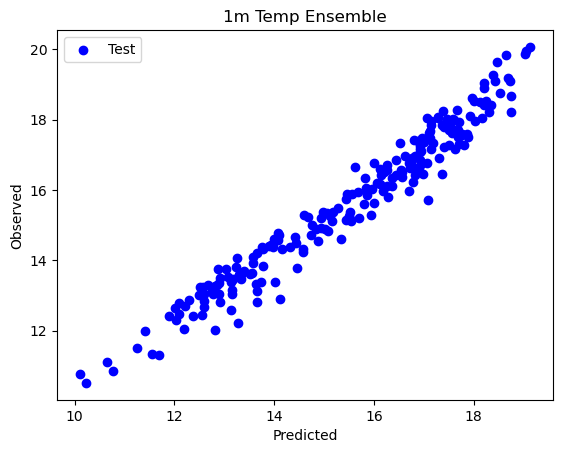

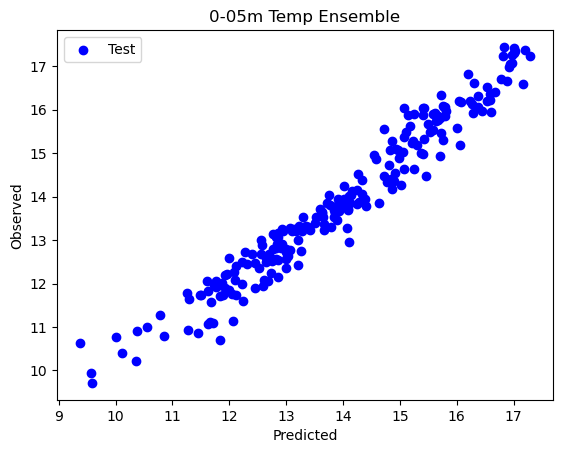

In [57]:
create_scatter_plot_test("1m Temp Ensemble", test["ts_cv_ensemble_pred_1m"], test["mean_1m_temp_degC"])
create_scatter_plot_test("0-05m Temp Ensemble", test["ts_cv_ensemble_pred_05m"], test["mean_0_5m_temp_degC"])

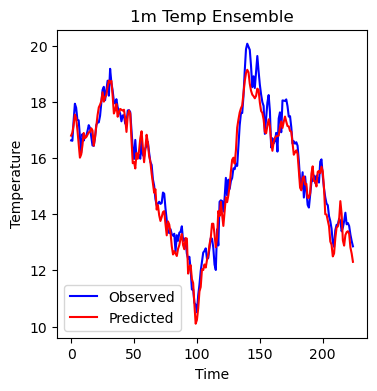

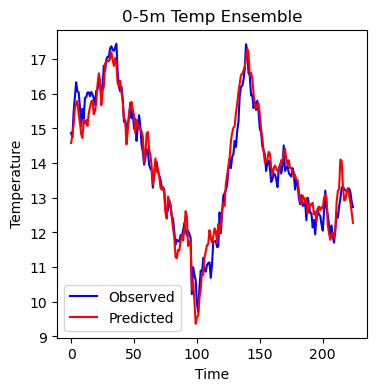

In [58]:
ts_plot(test["mean_1m_temp_degC"], test["ts_cv_ensemble_pred_1m"], "1m Temp Ensemble")
ts_plot(test["mean_0_5m_temp_degC"], test["ts_cv_ensemble_pred_05m"], "0-5m Temp Ensemble")


In [59]:
# Ensure 'date' is a datetime column
test['date'] = pd.to_datetime(test['date'])

# Extract unique years
years = test['date'].dt.year.unique()


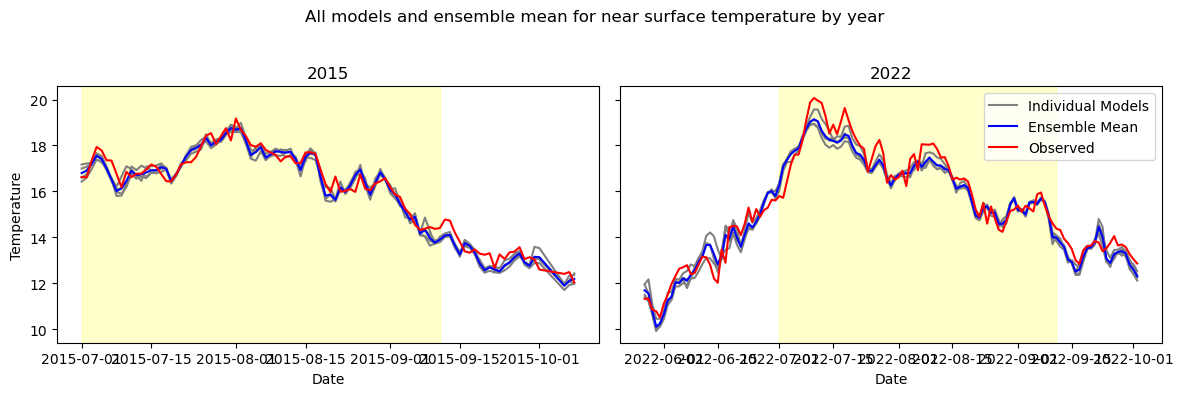

In [60]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_4"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["ts_cv_ensemble_pred_1m"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["mean_1m_temp_degC"], label="Observed", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for near surface temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

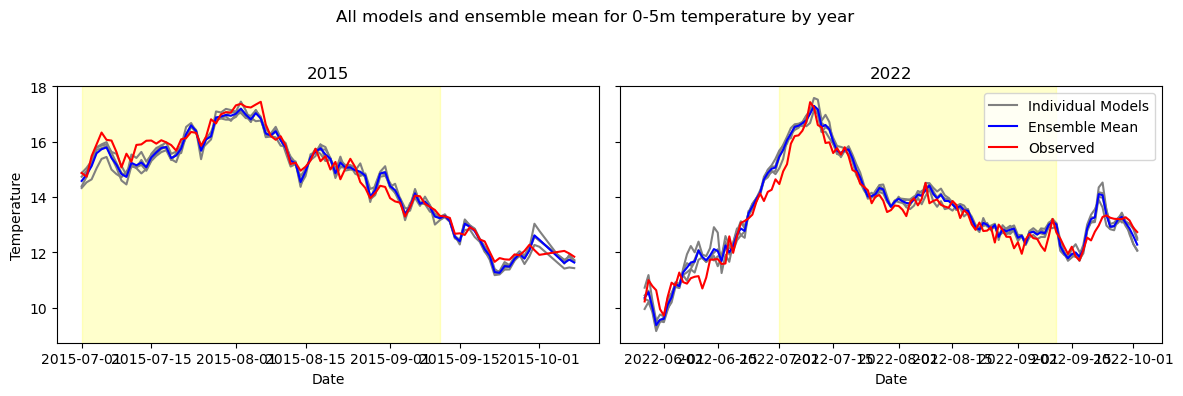

In [61]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_4"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["ts_cv_ensemble_pred_05m"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["mean_0_5m_temp_degC"], label="Observed", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for 0-5m temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

These actually look quite good. While the model doesn't capture the highest values at 1m, there were zero instances in the training/validation set with values that high, so it's not surprising that the model doesn't capture them. The model does a good job of capturing the general trends in the data and does very well with the high 0-5m values.


# Check differences in value from pumping changes

And now let's see how much of a difference there is between the control, no pump and full pump operation

In [62]:
control_preds = test[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]
nopump_preds = test_nopump[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]
fullpump_preds = test_fullpump[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]

turn_off_pump_diff = control_preds-nopump_preds
turn_off_pump_diff['date'] = test['date']
full_on_pump_diff = control_preds-fullpump_preds
full_on_pump_diff['date'] = test['date']


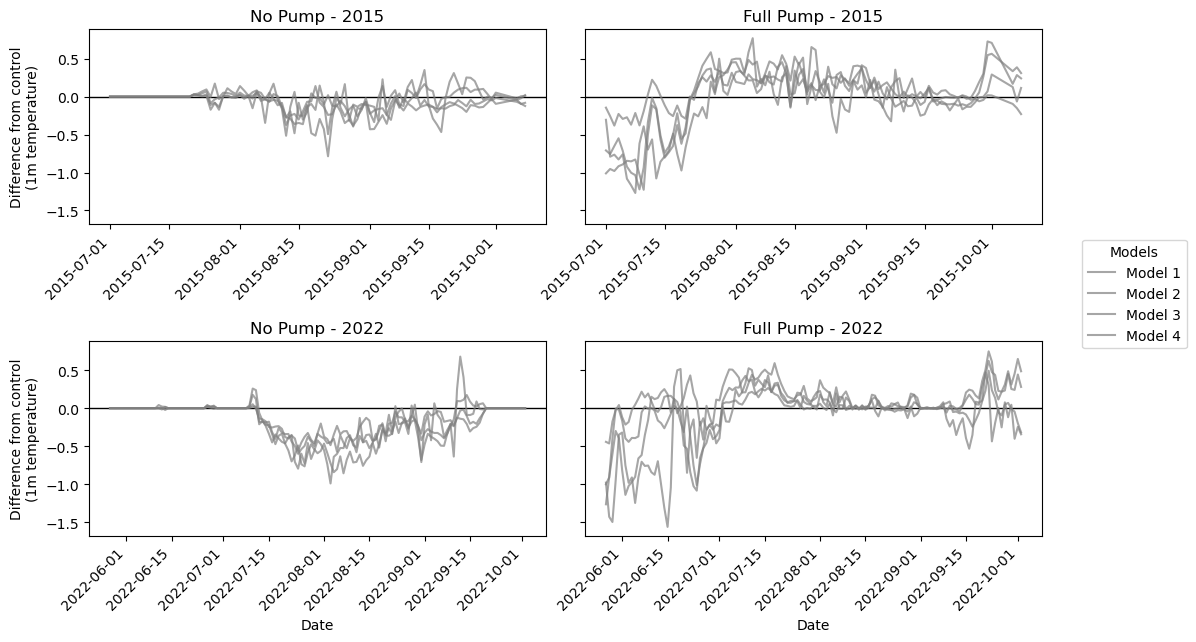

In [63]:
# Extract unique years
years = [2015, 2022]
ops = ["no pump", "full pump"]

# Create 2x2 subplots: rows = years, cols = ops
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), sharey=True)

for row_idx, year in enumerate(years):
    for col_idx, op in enumerate(ops):
        ax = axes[row_idx, col_idx]

        # Select appropriate dataframe
        if op == "no pump":
            selected_data = turn_off_pump_diff
        else:
            selected_data = full_on_pump_diff

        # Filter by year
        selected_data["date"] = pd.to_datetime(selected_data["date"])
        data_year = selected_data[selected_data["date"].dt.year == year]

        ax.axhline(0, color='black', linewidth=1, zorder=0)
        
        # Plot predictions
        lines = []
        for col in ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]:
            line, = ax.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
            lines.append(line)

        # Capture one set of lines for external legend
        if row_idx == 0 and col_idx == 0:
            lines_for_legend = lines

        ax.set_title(f"{op.title()} - {year}")
        if row_idx == 1:
            ax.set_xlabel("Date")
        if col_idx == 0:
            ax.set_ylabel("Difference from control\n(1m temperature)")

# Create a single external legend
fig.legend(lines_for_legend, ["Model 1", "Model 2", "Model 3", "Model 4"],
           loc="center left", bbox_to_anchor=(0.9, 0.5), title="Models")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on right for legend
plt.subplots_adjust(hspace=0.6)  # Adjust vertical spacing between rows

for ax_row in axes:
    for ax in ax_row:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')  # Align to end at the tick


plt.show()

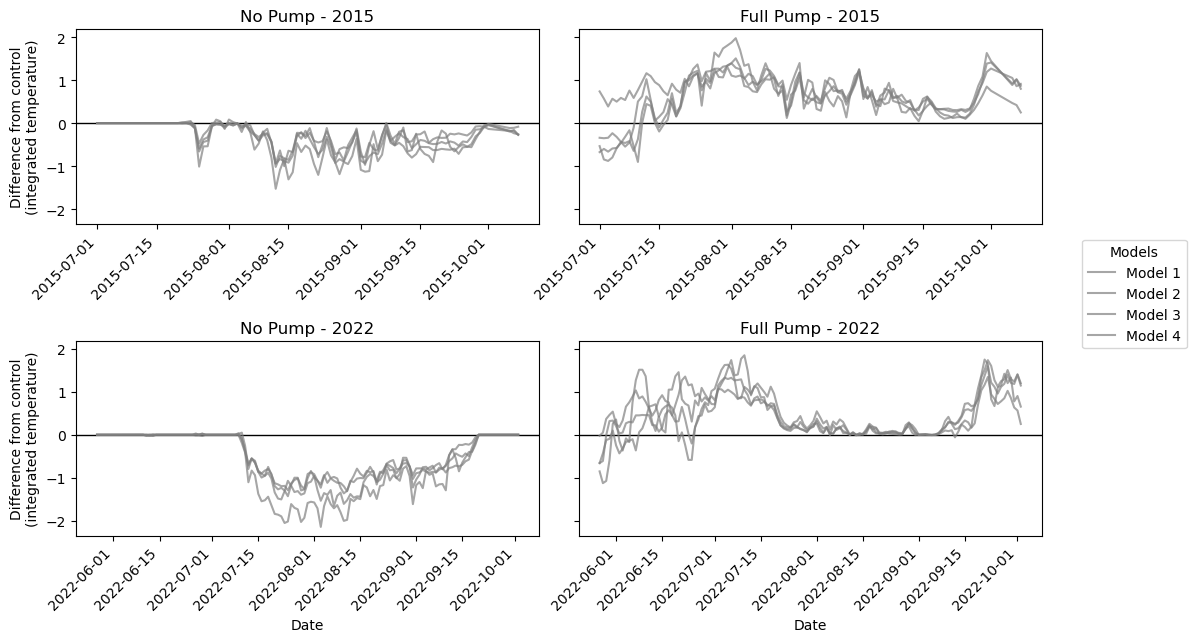

In [64]:
# Create 2x2 subplots: rows = years, cols = ops
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), sharey=True)

for row_idx, year in enumerate(years):
    for col_idx, op in enumerate(ops):
        ax = axes[row_idx, col_idx]

        # Select appropriate dataframe
        if op == "no pump":
            selected_data = turn_off_pump_diff
        else:
            selected_data = full_on_pump_diff

        # Filter by year
        selected_data["date"] = pd.to_datetime(selected_data["date"])
        data_year = selected_data[selected_data["date"].dt.year == year]

        ax.axhline(0, color='black', linewidth=1, zorder=0)

        # Plot predictions
        lines = []
        for col in ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]:
            line, = ax.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
            lines.append(line)

        # Capture one set of lines for external legend
        if row_idx == 0 and col_idx == 0:
            lines_for_legend = lines

        ax.set_title(f"{op.title()} - {year}")
        if row_idx == 1:
            ax.set_xlabel("Date")
        if col_idx == 0:
            ax.set_ylabel("Difference from control\n(integrated temperature)")

# Create a single external legend
fig.legend(lines_for_legend, ["Model 1", "Model 2", "Model 3", "Model 4"],
           loc="center left", bbox_to_anchor=(0.9, 0.5), title="Models")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on right for legend
plt.subplots_adjust(hspace=0.6)  # Adjust vertical spacing between rows

for ax_row in axes:
    for ax in ax_row:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')  # Align to end at the tick


## Create timeseries residual plot

Calculate residuals

In [65]:
test['res_1m_1'] = (test['pred_1m_1']) - (test['mean_1m_temp_degC'])
test['res_1m_2'] = (test['pred_1m_2']) - (test['mean_1m_temp_degC'])
test['res_1m_3'] = (test['pred_1m_3']) - (test['mean_1m_temp_degC'])
test['res_1m_4'] = (test['pred_1m_4']) - (test['mean_1m_temp_degC'])
test['res_1m_ensemble'] = (test['ts_cv_ensemble_pred_1m']) - (test['mean_1m_temp_degC'])

test['res_05m_1'] = test['pred_05m_1'] - test['mean_0_5m_temp_degC']
test['res_05m_2'] = test['pred_05m_2'] - test['mean_0_5m_temp_degC']
test['res_05m_3'] = test['pred_05m_3'] - test['mean_0_5m_temp_degC']
test['res_05m_4'] = test['pred_05m_4'] - test['mean_0_5m_temp_degC']
test['res_05m_ensemble'] = test['ts_cv_ensemble_pred_05m'] - test['mean_0_5m_temp_degC']


In [66]:
yit = test.filter(['mean_0_5m_temp_degC', 'mean_1m_temp_degC'])
yit = yit.shift(periods=1).rename(columns={'mean_0_5m_temp_degC': 'yit_mean_0_5m_temp_degC', 
                                     'mean_1m_temp_degC': 'yit_mean_1m_temp_degC'})

test = pd.concat([test, yit], axis=1)
test['res_yit_0_5m'] = test['yit_mean_0_5m_temp_degC'] - test['mean_0_5m_temp_degC']
test['res_yit_1m'] = (test['yit_mean_1m_temp_degC']) - (test['mean_1m_temp_degC'])


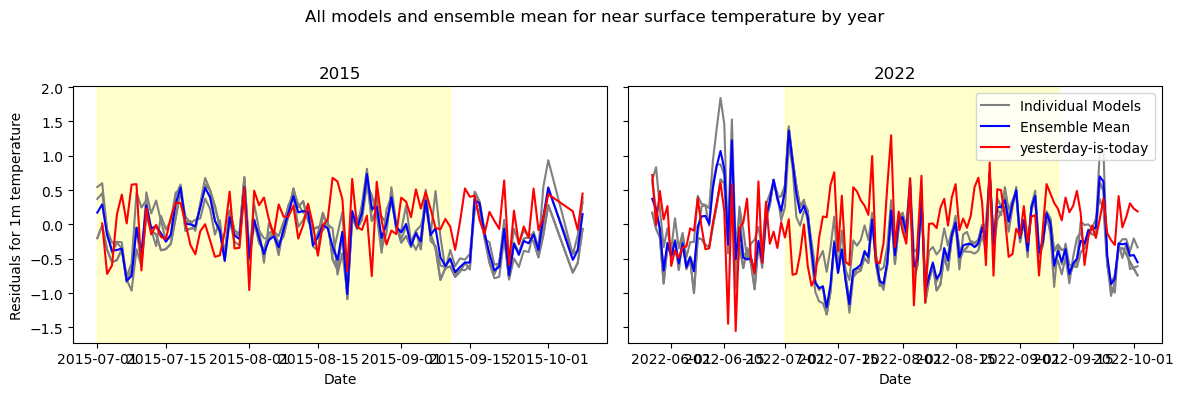

In [67]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["res_1m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_1"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_ensemble"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["res_yit_1m"], label="yesterday-is-today", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Residuals for 1m temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for near surface temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


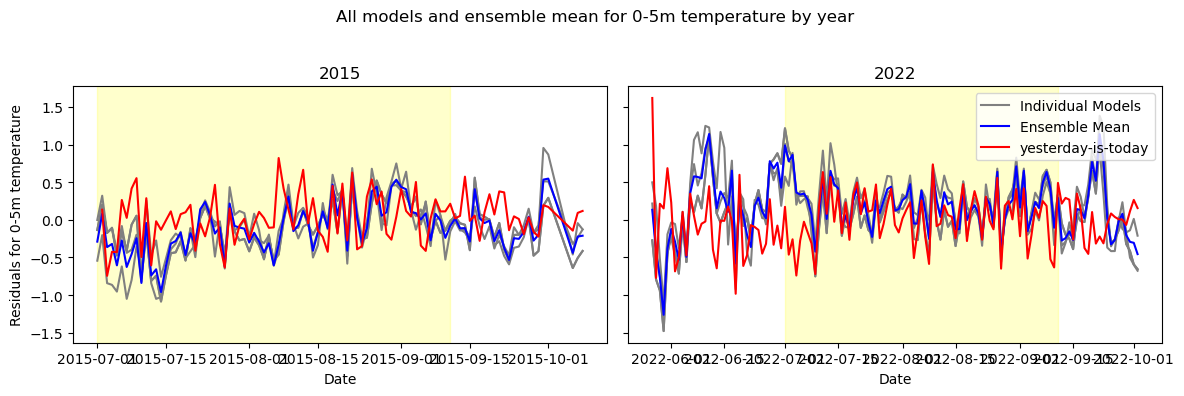

In [68]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["res_05m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_1"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_ensemble"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["res_yit_0_5m"], label="yesterday-is-today", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Residuals for 0-5m temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for 0-5m temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()